In [2]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
SUMMARY_JSON = Path(
    r"C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\nnUNet_results\Dataset002_HumanFemurProximalTibia\nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres\fold_0\validation\summary.json"
)

TRAIN_LOG = Path(
    r"C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\nnUNet_results\Dataset002_HumanFemurProximalTibia\nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres\fold_0\training_log_2026_5_11_23_35_00.txt"
)

OUT_DIR = Path(
    r"C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
with open(SUMMARY_JSON, "r") as f:
    summary = json.load(f)

femur_dice = summary["mean"]["1"]["Dice"]
prox_tibia_dice = summary["mean"]["2"]["Dice"]
overall_mean_dice = summary["foreground_mean"]["Dice"]

dice_scores = pd.DataFrame({
    "Structure": ["Femur", "Proximal Tibia", "Overall Mean"],
    "Dice Score": [femur_dice, prox_tibia_dice, overall_mean_dice]
})

dice_scores

,Structure,Dice Score
0,Femur,0.946709
1,Proximal Tibia,0.659279
2,Overall Mean,0.802994


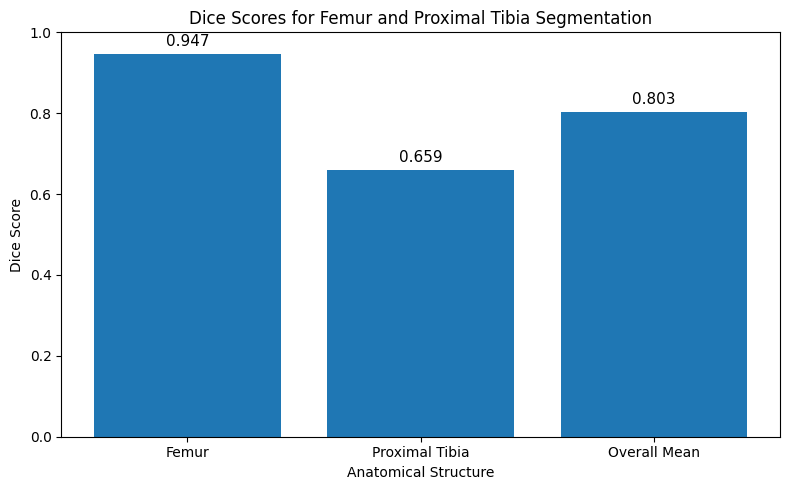

Saved: C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures\dice_scores_bar_graph.png


In [5]:
plt.figure(figsize=(8, 5))

plt.bar(
    dice_scores["Structure"],
    dice_scores["Dice Score"]
)

plt.ylim(0, 1.0)
plt.xlabel("Anatomical Structure")
plt.ylabel("Dice Score")
plt.title("Dice Scores for Femur and Proximal Tibia Segmentation")

for i, value in enumerate(dice_scores["Dice Score"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=11)

plt.tight_layout()

out_path = OUT_DIR / "dice_scores_bar_graph.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved:", out_path)

In [6]:
rows = []

for case in summary["metric_per_case"]:
    pred_file = Path(case["prediction_file"]).stem

    rows.append({
        "Case": pred_file,
        "Femur Dice": case["metrics"]["1"]["Dice"],
        "Proximal Tibia Dice": case["metrics"]["2"]["Dice"],
        "Femur IoU": case["metrics"]["1"]["IoU"],
        "Proximal Tibia IoU": case["metrics"]["2"]["IoU"],
    })

per_case_df = pd.DataFrame(rows)
per_case_df

,Case,Femur Dice,Proximal Tibia Dice,Femur IoU,Proximal Tibia IoU
0,vsd_0001.nii,0.775481,0.000000,0.633295,0.000000
1,vsd_0004.nii,0.973895,0.973129,0.949117,0.947664
2,vsd_0016.nii,0.977339,0.616402,0.955682,0.445506
3,vsd_0025.nii,0.975686,0.973402,0.952526,0.948183
4,vsd_0026.nii,0.971978,0.971922,0.945484,0.945378
5,vsd_0032.nii,0.974061,0.109459,0.949435,0.057898
6,vsd_0034.nii,0.978520,0.970642,0.957944,0.942959


In [7]:
csv_path = OUT_DIR / "validation_metrics_per_case.csv"
per_case_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)

Saved: C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures\validation_metrics_per_case.csv


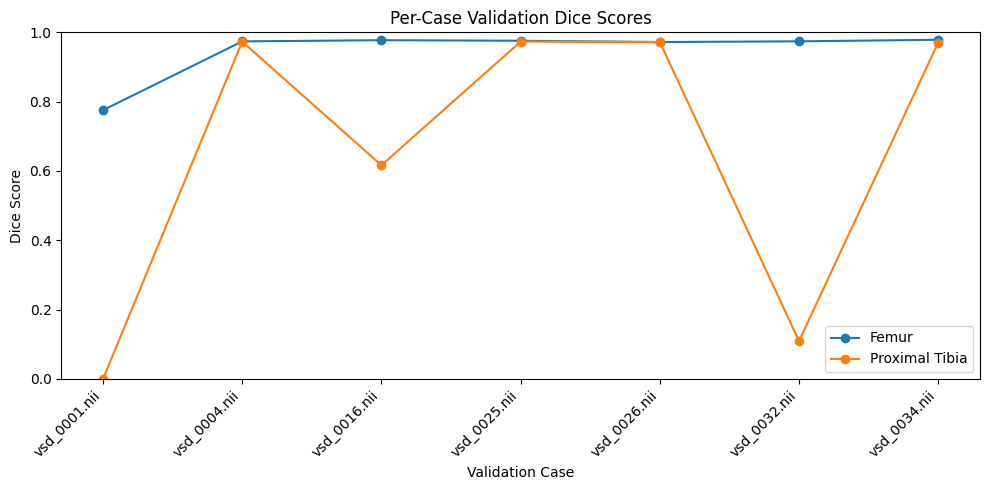

Saved: C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures\per_case_dice_scores.png


In [8]:
plt.figure(figsize=(10, 5))

x = range(len(per_case_df))

plt.plot(x, per_case_df["Femur Dice"], marker="o", label="Femur")
plt.plot(x, per_case_df["Proximal Tibia Dice"], marker="o", label="Proximal Tibia")

plt.xticks(x, per_case_df["Case"], rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.xlabel("Validation Case")
plt.ylabel("Dice Score")
plt.title("Per-Case Validation Dice Scores")
plt.legend()
plt.tight_layout()

out_path = OUT_DIR / "per_case_dice_scores.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved:", out_path)

In [9]:
log_text = TRAIN_LOG.read_text(encoding="utf-8", errors="ignore")

epochs = []
train_losses = []
val_losses = []
femur_pseudo_dice = []
tibia_pseudo_dice = []
epoch_times = []

current_epoch = None

for line in log_text.splitlines():
    epoch_match = re.search(r"Epoch\s+(\d+)", line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    train_match = re.search(r"train_loss\s+(-?\d+\.\d+)", line)
    if train_match and current_epoch is not None:
        train_losses.append(float(train_match.group(1)))

    val_match = re.search(r"val_loss\s+(-?\d+\.\d+)", line)
    if val_match and current_epoch is not None:
        val_losses.append(float(val_match.group(1)))

    dice_match = re.search(
        r"Pseudo dice\s+\[np\.float32\(([-+]?\d*\.\d+|\d+)\),\s*np\.float32\(([-+]?\d*\.\d+|\d+)\)\]",
        line
    )
    if dice_match and current_epoch is not None:
        epochs.append(current_epoch)
        femur_pseudo_dice.append(float(dice_match.group(1)))
        tibia_pseudo_dice.append(float(dice_match.group(2)))

    time_match = re.search(r"Epoch time:\s+(\d+\.\d+)", line)
    if time_match and current_epoch is not None:
        epoch_times.append(float(time_match.group(1)))

training_df = pd.DataFrame({
    "Epoch": epochs,
    "Femur Pseudo Dice": femur_pseudo_dice,
    "Proximal Tibia Pseudo Dice": tibia_pseudo_dice,
})

training_df.head()

,Epoch,Femur Pseudo Dice,Proximal Tibia Pseudo Dice
0,0,0.6557,0.0000
1,1,0.6961,0.3368
2,2,0.7385,0.1916
3,3,0.7734,0.3471
4,4,0.7739,0.4788


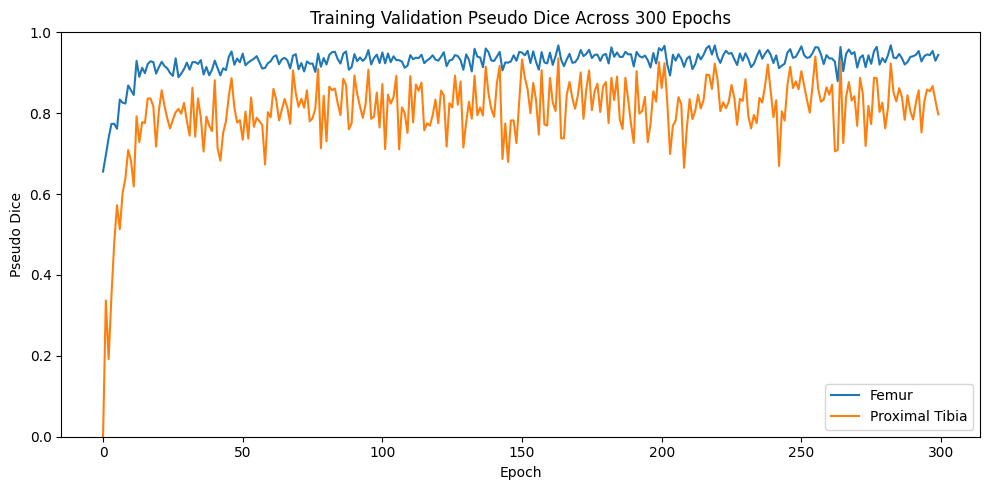

Saved: C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures\training_pseudo_dice_curve.png


In [10]:
plt.figure(figsize=(10, 5))

plt.plot(training_df["Epoch"], training_df["Femur Pseudo Dice"], label="Femur")
plt.plot(training_df["Epoch"], training_df["Proximal Tibia Pseudo Dice"], label="Proximal Tibia")

plt.xlabel("Epoch")
plt.ylabel("Pseudo Dice")
plt.title("Training Validation Pseudo Dice Across 300 Epochs")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

out_path = OUT_DIR / "training_pseudo_dice_curve.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved:", out_path)

In [11]:
csv_path = OUT_DIR / "training_pseudo_dice_by_epoch.csv"
training_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)

Saved: C:\vscode_windows\thesis\3d-segmentation-femur-tibia\nnunet\data\results_figures\training_pseudo_dice_by_epoch.csv
